# Day 17 — ACS Census Data: The Demographic Layer

---

## What you're building

A connection between your displacement risk score (Days 13/16) and the people who actually live in those zip codes. The question: does high displacement risk overlap with low-income, rent-burdened households — or is the pattern more complicated?

## What the ACS is

The **American Community Survey** is the Census Bureau's annual survey of ~3.5 million households. The 5-year estimates average five years of data to produce reliable numbers at small geographies (zip codes, block groups, census tracts).

You already use the math it runs on: the **margin of error** in ACS tables uses the same z-score logic you teach. A 90% confidence interval means the true value is within ±MOE of the estimate 90% of the time.

## Key variables today

| Variable code | What it measures | Why it matters |
|---|---|---|
| `B19013_001E` | Median household income | Economic capacity |
| `B25071_001E` | Median gross rent as % of income | Rent burden — the standard affordability measure |
| `B25064_001E` | Median gross rent (dollars) | Absolute housing cost |
| `B01003_001E` | Total population | Context |

**Rent burden** = gross rent ÷ income. HUD defines 30%+ as burdened, 50%+ as severely burdened.

## How Census data access works

The Census Bureau has a free API. You send a URL request with:
- Which dataset (ACS 5-year)
- Which variables (the codes above)
- Which geography (zip codes in New York)
- Your API key (free, instant at census.gov/developers)

It returns JSON that you load into a DataFrame.

## How today is structured

- **Boilerplate** (API call, data loading, column cleanup) — already written.
- **Data work** (filtering, calculating, merging, normalizing) — your job.
- After each data cell, predict the output before running.

In [2]:
# CELL 1 — Imports. (Boilerplate.)
import pandas as pd
import requests
import matplotlib.pyplot as plt

## MANUAL STEP — Get a Census API key

1. Go to **api.census.gov/data/key_signup.html**
2. Enter your name and email — key arrives in under a minute
3. Paste it into Cell 2 below where it says `YOUR_KEY_HERE`

The key is free, no credit card, no expiration.

In [13]:
# CELL 2 — Download ACS data for all NYC zip codes. (Boilerplate.)
#
# What this does: sends one request to the Census API asking for
# 4 variables across every zip code in New York State.
# We'll filter to Bushwick zips in the next cell.
#
# 'zip code tabulation area' is the Census term for zip code geography.
# 'in state:36' = New York State (FIPS code 36).

API_KEY = '72328d2890bb6c7d71a358f0574a8d1477d24dc1'   # paste your key here

url = (
    'https://api.census.gov/data/2022/acs/acs5'
    '?get=B19013_001E,B25071_001E,B25064_001E,B01003_001E'
    '&for=zip%20code%20tabulation%20area:*'
    
    f'&key={API_KEY}'
)



response = requests.get(url)


data = response.json()

# The first row is column headers, the rest is data
df_acs = pd.DataFrame(data[1:], columns=data[0])

# Rename columns to readable names
df_acs = df_acs.rename(columns={
    'B19013_001E': 'median_income',
    'B25071_001E': 'rent_burden_pct',
    'B25064_001E': 'median_rent',
    'B01003_001E': 'population',
    'zip code tabulation area': 'zip'
})

print(df_acs.shape)
print(df_acs.head(3))

(33774, 5)
  median_income rent_burden_pct median_rent population    zip
0         17526            28.4         401      16834  00601
1         20260            29.5         459      37642  00602
2         17703            29.1         448      49075  00603


**Before Cell 3:** The ACS returns all values as strings — even numbers. What method do you need to call before you can filter or do math on `median_income`?

IsNumeric() and I need to do this for the zipcodes I neeed to see

In [18]:
# CELL 3 — Filter to Bushwick zip codes and convert types.
#
# Steps:
#   1. Filter df_acs to zip isin(['11206', '11207', '11221', '11237'])
#      Store as df_bw_acs.

df_bw_acs = df_acs[df_acs['zip'].isin(['11206', '11207', '11221', '11237'])]
#   2. Convert median_income, rent_burden_pct, median_rent, population
#      all to numeric with errors='coerce'.
df_bw_acs['median_income'] = pd.to_numeric(df_bw_acs['median_income'], errors='coerce')
df_bw_acs['rent_burden_pct'] = pd.to_numeric(df_bw_acs['rent_burden_pct'], errors='coerce')
df_bw_acs['population'] = pd.to_numeric(df_bw_acs['population'], errors='coerce')
df_bw_acs['median_rent'] = pd.to_numeric(df_bw_acs['median_rent'], errors='coerce')

#      Gotcha: Census uses -666666666 for suppressed/missing values — these
#      become NaN after to_numeric if you replace them first:
df_bw_acs = df_bw_acs.replace(-666666666, pd.NA)
print(df_bw_acs[['zip','median_income','rent_burden_pct','median_rent']])
#
# Expected: 3-4 rows, income somewhere in the $40k-$80k range for Bushwick.

# TODO


        zip  median_income  rent_burden_pct  median_rent
2850  11206          51507             31.4         1434
2851  11207          52569             35.6         1476
2865  11221          77600             31.0         1937
2880  11237          79136             33.1         1998


**Before Cell 4:** `rent_burden_pct` is median gross rent as a percentage of income. If a zip shows `35.0`, what does that mean in plain English for the typical household there? Is that burdened by HUD's definition?

This means that 35% of their total household income goes to rent, this would qualify them as rent burdened if not mistaken rent should take at most 33% of your income. 

In [26]:
# CELL 4 — Rebuild df_risk and merge with ACS data.
#
# You've built df_risk twice now (Days 13 and 16).
# Build it again from the three ingredients — no notes.
# You need df_risk with columns: zip_str, risk_score
# CELL 3 — Ingredient 1: median price per unit by zip code.
#
# You've written this pipeline before (Days 10 and 13).
# Steps:
#   1. Load acris_bushwick_clean.csv → df_sales
df_sales = pd.read_csv('../data/acris_bushwick_clean.csv')
#   2. Load pluto.csv → df_pluto
df_pluto = pd.read_csv('../data/pluto.csv')
#   3. Filter df_pluto to community board 304.0 → pluto_bw

df_pluto['community board'] = pd.to_numeric(df_pluto['community board'], errors='coerce')
pluto_bw = df_pluto[df_pluto['community board'] == 304.0]

#   4. Merge df_sales + pluto_bw on BOROUGH_x/BLOCK/LOT = borocode/Tax block/Tax lot

bw_merged = pd.merge(df_sales, df_pluto, left_on=['BOROUGH_x', 'BLOCK', 'LOT'], right_on=['borocode','Tax block', 'Tax lot'])
#   5. Convert unitsres to numeric (errors='coerce')

bw_merged['unitsres'] = pd.to_numeric(bw_merged['unitsres'], errors='coerce')

#   6. Filter: community board 304.0, unitsres 1-99 → df_residential (.copy())
df_residential = bw_merged[(bw_merged['community board'] == 304.0) & (bw_merged['unitsres'] > 0) & (bw_merged['unitsres'] < 100)].copy()

#   7. New column: price_per_unit = DOC. AMOUNT / unitsres
df_residential['price_per_unit'] = df_residential['DOC. AMOUNT'] / df_residential['unitsres']
#   8. groupby postcode, median price_per_unit → df_price_by_zip
df_price_by_zip = df_residential.groupby('postcode')['price_per_unit'].median()
# Sanity check: print(df_price_by_zip)
print(df_price_by_zip)
# Expected: 3 rows, postcodes 11207/11221/11237

# TODO
# CELL 4 — Ingredient 2: median 311 response hours by zip code.
#
# Steps:
#   1. Load your 311 CSV with usecols: Created Date, Closed Date,
#      Incident Zip, Complaint Type, Borough → df_311
df_311 = pd.read_csv('../data/311_cleaned.csv', usecols=['Created Date', 'Closed Date', 'Incident Zip', 'Problem (formerly Complaint Type)', 'Borough'])
#   2. Filter to Borough == 'BROOKLYN' → df_brooklyn (.copy())
df_brooklyn = (df_311[df_311['Borough'] == 'BROOKLYN']).copy()
#   3. Parse Created Date and Closed Date to datetime

df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])
df_brooklyn['Closed Date'] = pd.to_datetime(df_brooklyn['Closed Date'])
#   4. New column: Response Hours = (Closed - Created).dt.total_seconds() / 3600
df_brooklyn['Response Hours'] = ((df_brooklyn['Closed Date'] - df_brooklyn['Created Date']).dt.total_seconds()) / 3600
#   5. Filter: Response Hours > 0
df_brooklyn = (df_brooklyn[df_brooklyn['Response Hours'] > 0])
#   6. Filter: Incident Zip isin([11206, 11221, 11237]) → df_bushwick_311
df_bushwick_311 = df_brooklyn[df_brooklyn['Incident Zip'].isin([11207, 11221, 11237])]
#   7. groupby Incident Zip, median Response Hours → df_311_by_zip
df_311_by_zip = df_bushwick_311.groupby('Incident Zip')['Response Hours'].median()
print(df_311_by_zip)
#
# CELL 5 — Ingredient 3: median FAR gap by zip code.
#
# Steps:
#   1. Load pluto.csv with usecols: community board, postcode, builtfar, residfar
pluto_brooklyn = pd.read_csv('../data/pluto.csv', usecols = ['community board', 'postcode', 'builtfar', 'residfar'])                                                                 
#   2. Filter to community board 304.0 → pluto_bushwick (.copy())
pluto_brooklyn['community board'] = pd.to_numeric(pluto_brooklyn['community board'], errors='coerce')
pluto_bushwick = (pluto_brooklyn[pluto_brooklyn['community board'] == 304.0])
#   3. Convert builtfar and residfar to numeric (errors='coerce')
pluto_bushwick['builtfar'] = pd.to_numeric(pluto_bushwick['builtfar'], errors='coerce')
pluto_bushwick['residfar'] = pd.to_numeric(pluto_bushwick['residfar'], errors='coerce')
#   4. Filter: residfar > 0 (exclude manufacturing zones)
pluto_bushwick = pluto_bushwick[pluto_bushwick['residfar'] > 0]

#   5. New column: far_gap = (residfar - builtfar).clip(lower=0)
pluto_bushwick['far_gap'] = (pluto_bushwick['residfar'] - pluto_bushwick['builtfar']).clip(lower=0)
#   6. groupby postcode, median far_gap → df_far_by_zip
df_far_by_zip = pluto_bushwick.groupby('postcode')['far_gap'].median()
# Sanity check: print(df_far_by_zip)
print(pluto_bushwick['residfar'].dtype)
print(pluto_bushwick['residfar'].describe())

print(df_far_by_zip)
#Steps:
#   1. reset_index() on each Series, rename columns to ['zip', 'price_per_unit'],
#      ['zip', 'response_hours'], ['zip', 'far_gap']
price_norm = df_price_by_zip.reset_index()
price_norm.columns = ['zip', 'price_per_unit']

response_norm = df_311_by_zip.reset_index()
response_norm.columns = ['zip', 'Response Hours']

far_norm = df_far_by_zip.reset_index()
far_norm.columns = ['zip', 'far_gap']
#   2. Outer merge all three on 'zip' → df_risk
df_risk = price_norm.merge(response_norm, on='zip').merge(far_norm, on='zip')

print(df_risk)

#   3. Fill NaN price with median (impute 11206)
df_risk['price_per_unit'] = df_risk['price_per_unit'].fillna(df_risk['price_per_unit'].median())

#   4. Normalize each column to 0-1:
#        df_risk['price_norm']    = (value - min) / (max - min)
df_risk['price_norm'] = (df_risk['price_per_unit'] - df_risk['price_per_unit'].min()) / (df_risk['price_per_unit'].max() - df_risk['price_per_unit'].min())
#        df_risk['response_norm'] = same
df_risk['response_norm'] = (df_risk['Response Hours'] - df_risk['Response Hours'].min()) / (df_risk['Response Hours'].max() - df_risk['Response Hours'].min())
#        df_risk['far_norm']      = same
df_risk['far_norm'] = (df_risk['far_gap'] - df_risk['far_gap'].min()) / (df_risk['far_gap'].max() - df_risk['far_gap'].min())
#   5. risk_score = (price_norm + response_norm + far_norm) / 3
df_risk['risk_score'] = (df_risk['price_norm'] + df_risk['response_norm'] + df_risk['far_norm']) / 3
#   6. Convert zip to string for GeoJSON matching:
df_risk['zip_str'] = df_risk['zip'].astype(int).astype(str)
#
print(df_risk[['zip_str', 'risk_score']])
# Then merge df_risk and df_bw_acs on zip.
df_combined = pd.merge(
    df_risk, df_bw_acs,
    left_on=['zip_str'],
    right_on=['zip']  # adjust to whatever that print shows
)
# Watch the types: df_risk['zip_str'] is a string, df_bw_acs['zip'] is a string.
# Use left_on='zip_str', right_on='zip'.
# Store as df_combined.
#
print(df_combined.shape) and print(df_combined.columns.tolist())

# TODO — rebuild df_risk first, then merge


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_2706/3430976758.py:13: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_pluto = pd.read_csv('../data/pluto.csv')


postcode
11207.0    270000.000000
11221.0    213750.000000
11237.0    191666.666667
Name: price_per_unit, dtype: float64


/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_2706/3430976758.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_brooklyn['Created Date'] = pd.to_datetime(df_brooklyn['Created Date'])


Incident Zip
11207.0    7.901667
11221.0    4.599444
11237.0    2.166111
Name: Response Hours, dtype: float64
float64
count    10495.000000
mean         2.424062
std          0.200869
min          0.750000
25%          2.430000
50%          2.430000
75%          2.430000
max          4.660000
Name: residfar, dtype: float64
postcode
11206.0    0.795
11207.0    0.930
11221.0    0.940
11237.0    0.630
Name: far_gap, dtype: float64
       zip  price_per_unit  Response Hours  far_gap
0  11207.0   270000.000000        7.901667     0.93
1  11221.0   213750.000000        4.599444     0.94
2  11237.0   191666.666667        2.166111     0.63
  zip_str  risk_score
0   11207    0.989247
1   11221    0.568723
2   11237    0.000000
(3, 14)


**Before Cell 5:** Look at your df_combined columns. You have `risk_score`, `median_income`, and `rent_burden_pct` all in one place. Before you plot: which zip do you expect to have the lowest income? Which do you expect to have the highest rent burden?

I expect 11207 to have both the lowest income and highest rent burden

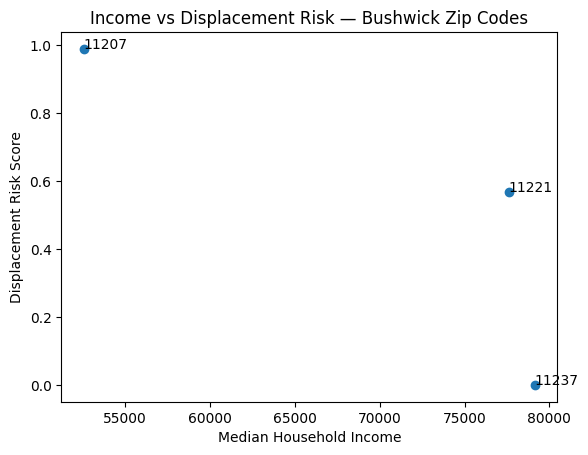

In [32]:
# CELL 5 — Scatter: risk score vs median income.
#
plt.scatter(x=df_combined['median_income'], y=df_combined['risk_score'])

for _, row in df_combined.iterrows():
    plt.annotate(row['zip_str'], (row['median_income'], row['risk_score']))

plt.xlabel('Median Household Income')
plt.ylabel('Displacement Risk Score')
plt.title('Income vs Displacement Risk — Bushwick Zip Codes')
plt.show()

# What pattern do you see? Does lower income = higher risk, or is it messier?

# TODO


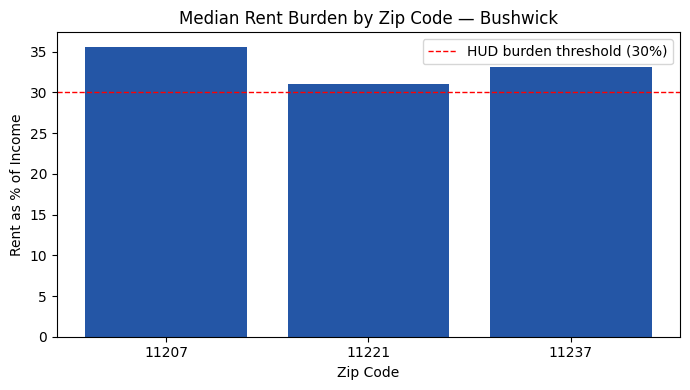

In [33]:
# CELL 6 — Bar chart: rent burden by zip. (Boilerplate — already written.)
#
# rent_burden_pct is the median share of income going to rent.
# The red dashed line marks 30% — HUD's definition of rent burdened.

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_combined['zip_str'], df_combined['rent_burden_pct'], color='#2456A6')
ax.axhline(30, color='red', linestyle='--', linewidth=1, label='HUD burden threshold (30%)')
ax.set_title('Median Rent Burden by Zip Code — Bushwick')
ax.set_xlabel('Zip Code')
ax.set_ylabel('Rent as % of Income')
ax.legend()
plt.tight_layout()
plt.show()

**Critical thinking pause:**
- Which zip code has the highest rent burden? Is it the same one with the highest displacement risk score?
- `rent_burden_pct` is a median — half of households are above it, half below. What does it mean for displacement if the median is already above 30%?
- Your risk score doesn't include income or rent burden yet. If you added `rent_burden_pct` as a fourth ingredient, how would you normalize it? Which direction — higher burden = higher risk, or lower?
- ACS data is from 2022. Your ACRIS sales are from 2020 onward. Is that a meaningful mismatch? What could change in 2-3 years that would make the income data feel stale?

11207 as i predicted had the highest rent burden, and it's also the same place with the same high displaacement score 

This means that most of the people living in the zip code are already rent burdened

A higher rent burden would mean a higher chance of displacement because as rents continue to increase people would be more likely to live somewhere else for cheaper rents

New residents pushing the incomes higher especially in NYC a lot can change in a year especially coming out of the pandemic

*(Write your answers here)*

## Day 17 Recap

| What you did | Why it matters |
|---|---|
| Census API request | Real-world data access — no CSV download, just a URL |
| -666666666 suppression values | Government data has sentinel values for missing — always check |
| Rebuilt df_risk from memory | The third time is the test — fluency means it flows without notes |
| Income + rent burden layer | Demographic context turns a price map into a displacement argument |

## Close-out

In your own words: what is rent burden, how does the Census measure it, and why is 30% the threshold that matters?

Rent burden is the median amount of money one pays in relation to their monthly household income. The census measures it as how much rent is a percentage of salary, and 30% is the threshold which means at most 30% of your income should go to rent but seldom does that happen and the percentage is a lot higher.

### What's coming on Day 18
GeoPandas spatial joins — connecting PLUTO parcels to Census block groups by location instead of zip code. More precise than zip, more useful for block-level analysis.